In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../data/togo-dapaong_qc.csv")
df.head()

,Unnamed: 0,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,0,2021-10-25 00:01,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977.0,0.0,0.0,24.7,24.4,NaN
1,1,2021-10-25 00:02,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977.0,0.0,0.0,24.7,24.4,NaN
2,2,2021-10-25 00:03,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977.0,0.0,0.0,24.7,24.4,NaN
3,3,2021-10-25 00:04,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977.0,0.0,0.0,24.7,24.4,NaN
4,4,2021-10-25 00:05,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977.0,0.0,0.0,24.7,24.4,NaN


# Summary Statistics & Missing-Value Report

In [ ]:
df.describe()

,Unnamed: 0,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.00000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,262799.50000,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
std,151727.79508,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN
min,0.00000,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,131399.75000,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,262799.50000,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,394199.25000,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,525599.00000,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
Timestamp,0
GHI,0
DNI,0
DHI,0
ModA,0
ModB,0
Tamb,0
RH,0
WS,0


# Outlier Detection & Basic Cleaning

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
Timestamp,0
GHI,0
DNI,0
DHI,0
ModA,0
ModB,0
Tamb,0
RH,0
WS,0


In [ ]:
data_cols = ['ModA', 'ModB', 'WS', 'WSgust', 'GHI', "DNI", 'DHI']
for col in data_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(outliers)

        Unnamed: 0         Timestamp     GHI    DNI    DHI    ModA    ModB  \
674            674  2021-10-25 11:15  1094.0  706.7  490.8  1140.0  1126.0   
675            675  2021-10-25 11:16  1085.0  696.1  491.6  1133.0  1118.0   
681            681  2021-10-25 11:22  1028.0  578.4  528.4  1063.0  1049.0   
707            707  2021-10-25 11:48  1036.0  690.2  434.8  1068.0  1056.0   
708            708  2021-10-25 11:49  1040.0  715.7  411.5  1068.0  1056.0   
...            ...               ...     ...    ...    ...     ...     ...   
522079      522079  2022-10-22 13:20  1022.0  662.3  425.8  1070.1  1026.0   
522080      522080  2022-10-22 13:21  1026.0  695.2  400.0  1070.1  1027.0   
522081      522081  2022-10-22 13:22  1060.0  733.3  405.0  1107.0  1062.0   
522087      522087  2022-10-22 13:28  1040.0  725.8  399.7  1086.5  1043.0   
522088      522088  2022-10-22 13:29  1024.0  727.0  381.9  1069.1  1025.0   

        Tamb    RH   WS  WSgust  WSstdev     WD  WDstdev   BP  

### z-scores

In [6]:
key_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
mean = df[key_cols].mean()
std = df[key_cols].std()
z_score = (df[key_cols] - mean) / std
z_score

,GHI,DNI,DHI,ModA,ModB,WS,WSgust
0,-0.742011,-0.747454,-0.768645,-0.744933,-0.744182,-1.007280,-1.137348
1,-0.742011,-0.747454,-0.768645,-0.744933,-0.744182,-0.821183,-0.768499
2,-0.742011,-0.747454,-0.768645,-0.744933,-0.744182,-0.728134,-0.916039
3,-0.741711,-0.747454,-0.768645,-0.744933,-0.744182,-0.728134,-0.768499
4,-0.741711,-0.747454,-0.768645,-0.744933,-0.744182,-0.635086,-0.768499
...,...,...,...,...,...,...,...
41604,-0.747725,-0.747454,-0.768645,-0.744933,-0.744182,-0.914231,-1.137348
41605,-0.748026,-0.747454,-0.768645,-0.744933,-0.744182,-1.193377,-1.137348
41606,-0.748026,-0.747454,-0.768645,-0.744933,-0.744182,-1.286425,-1.432427
41607,-0.747725,-0.747454,-0.768645,-0.744933,-0.744182,-1.193377,-1.432427


In [ ]:
outliers_three = abs(z_score) > 3
rows_with_outlier = df[outliers_three.any(axis=1)]
rows_with_outlier

,Unnamed: 0,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
4985,4985,2021-10-28 11:06,1139.0,805.1,466.1,1172.0,1154.0,29.8,70.8,2.2,2.6,0.4,298.6,13.4,977,0,0.0,44.7,50.2,NaN
5410,5410,2021-10-28 18:11,-1.2,0.0,0.0,0.0,0.0,29.7,63.5,6.6,9.7,1.6,122.1,14.3,976,0,0.0,30.0,29.5,NaN
5411,5411,2021-10-28 18:12,-1.0,0.0,0.0,0.0,0.0,29.3,62.4,6.9,8.9,1.2,128.7,10.8,976,0,0.0,29.9,29.5,NaN
5413,5413,2021-10-28 18:14,-0.8,0.0,0.0,0.0,0.0,28.6,63.7,7.1,8.9,1.1,127.9,14.4,976,0,0.0,29.5,29.2,NaN
5420,5420,2021-10-28 18:21,-1.3,0.0,0.0,0.0,0.0,27.7,64.5,6.1,8.9,1.3,123.2,14.4,977,0,0.0,28.4,28.2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510473,510473,2022-10-14 11:54,709.5,63.7,629.8,703.1,694.9,30.2,66.6,3.5,4.4,0.8,167.0,15.2,977,0,0.0,46.8,51.6,NaN
510474,510474,2022-10-14 11:55,677.8,40.6,621.7,670.1,662.2,30.2,66.7,2.8,3.6,0.6,175.1,19.7,977,0,0.0,46.8,51.6,NaN
510475,510475,2022-10-14 11:56,659.5,29.7,614.9,651.0,643.4,30.3,66.1,4.1,4.9,0.5,174.0,11.5,977,0,0.0,46.8,51.6,NaN
510476,510476,2022-10-14 11:57,660.1,40.7,605.6,653.2,645.6,30.2,66.0,3.7,4.6,0.7,165.4,21.6,977,0,0.0,46.6,51.4,NaN


### impute (median) missing values in key columns

In [12]:
key_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
median = df[key_cols].median()
df[key_cols] = df[key_cols].fillna(median)

In [8]:
df.isna().sum()

,0
Unnamed: 0,0
Timestamp,0
GHI,0
DNI,0
DHI,0
ModA,0
ModB,0
Tamb,1
RH,1
WS,0


### export

In [ ]:
df.to_csv("../data/togo-dapaong_qc_clean.csv")

## Time Series Analysis

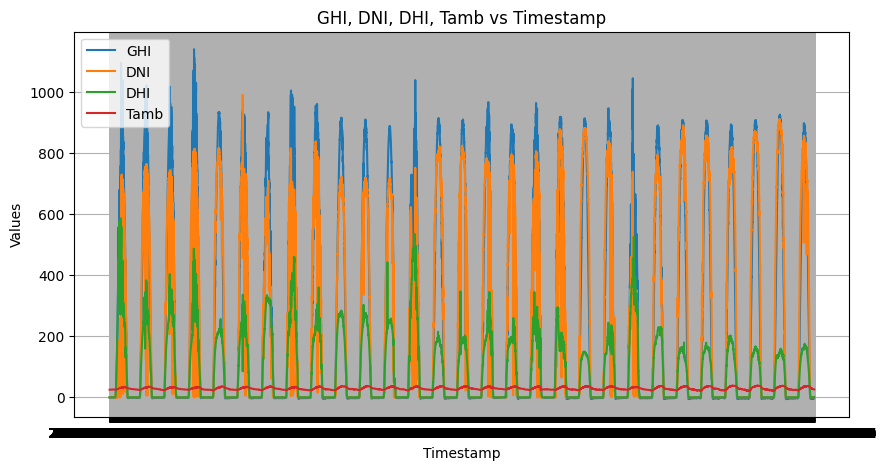

In [20]:
cols = ['GHI', 'DNI', 'DHI', 'Tamb']
plt.figure(figsize=(10,5))
for col in cols:
    plt.plot(df['Timestamp'], df[col], label=col)


plt.xlabel("Timestamp")
plt.ylabel("Values")
plt.title("GHI, DNI, DHI, Tamb vs Timestamp")
plt.legend()
plt.grid(True)
plt.show()

### Cleaning Impact

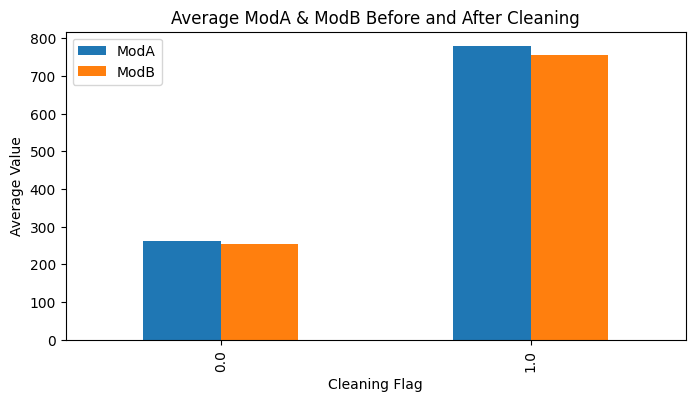

In [9]:
clean_avg = df.groupby('Cleaning')[['ModA','ModB']].mean()

clean_avg.plot(kind='bar',  figsize=(8,4))
plt.title('Average ModA & ModB Before and After Cleaning')
plt.ylabel('Average Value')
plt.xlabel('Cleaning Flag')
plt.show()

# Correlation & Relationship Analysis

### Heatmap of correlations

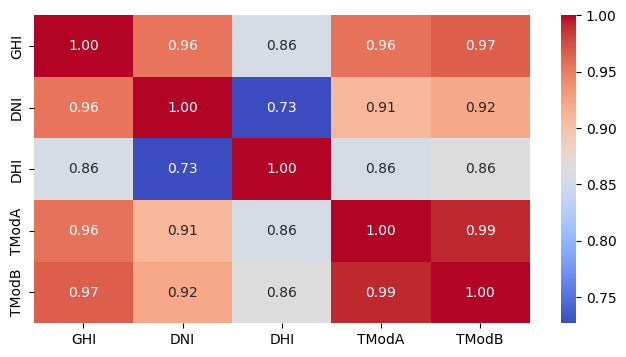

In [10]:
cols = ['GHI', 'DNI', 'DHI', 'TModA','TModB']
corr_matrix = df[cols].corr()
plt.figure(figsize=(8,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()


### Scatter plots

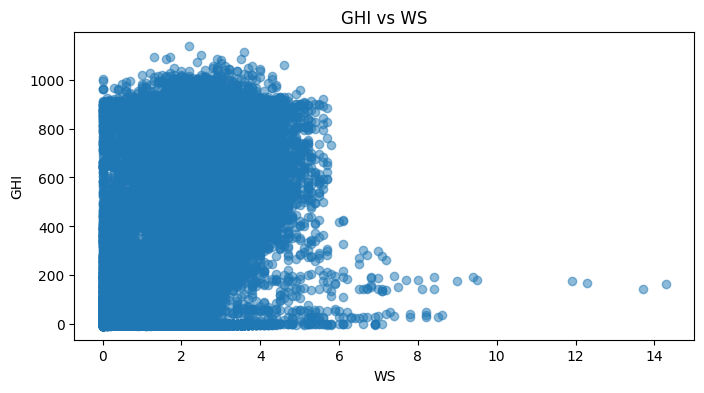

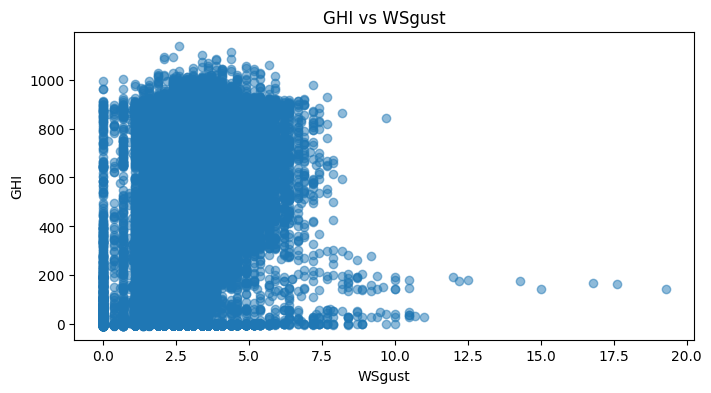

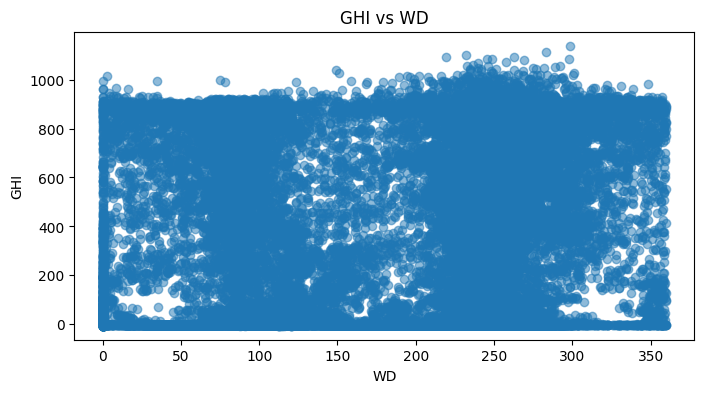

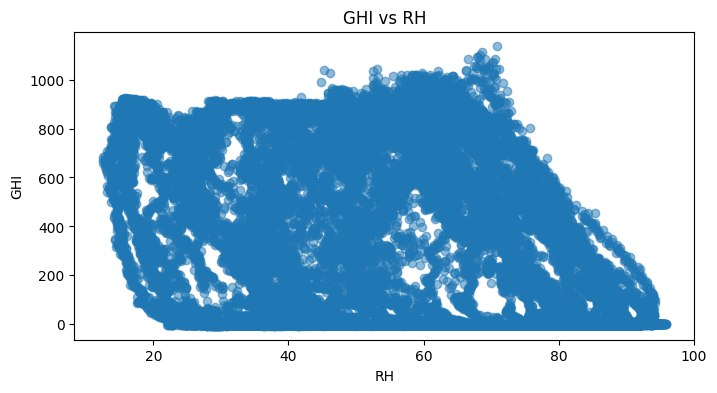

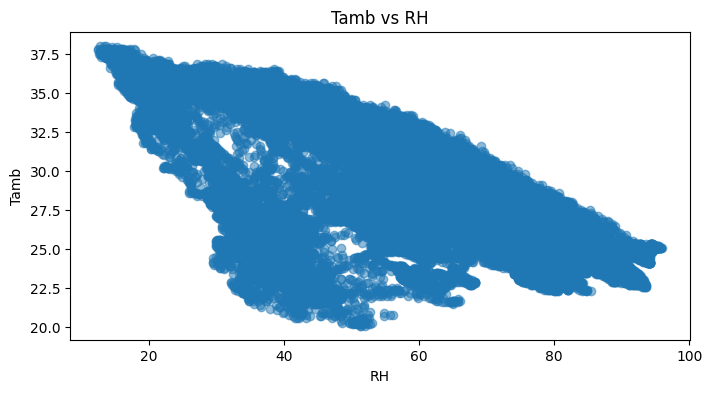

In [19]:
def plot(xcol, ycol):
        plt.figure(figsize=(8,4))
        plt.scatter(df[xcol], df[ycol], alpha=0.5)
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.title(f"{ycol} vs {xcol}")
        plt.show()

def pltscatter():
    cols = ['WS', 'WSgust','WD', 'RH']

    for col in cols:
        plot(col, "GHI")

    plot("RH", "Tamb")


pltscatter()

# Wind & Distribution Analysis

### Wind rose or radial bar plot of WS/WD.

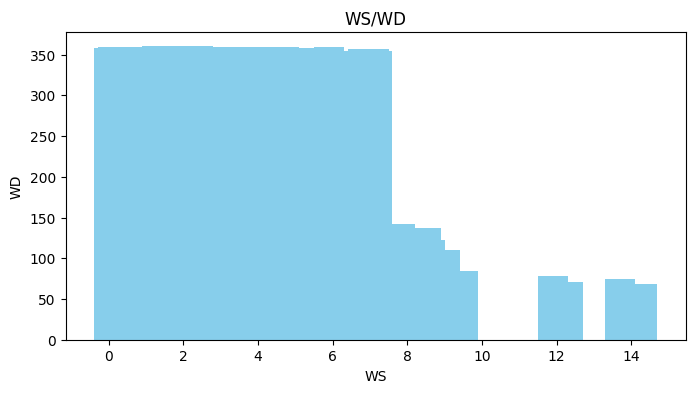

In [18]:
plt.figure(figsize=(8, 4))
plt.bar(df['WS'], df['WD'], color='skyblue')
plt.title('WS/WD')
plt.xlabel("WS")
plt.ylabel('WD')
plt.show()

### Histograms for GHI and one other variable (e.g. WS)

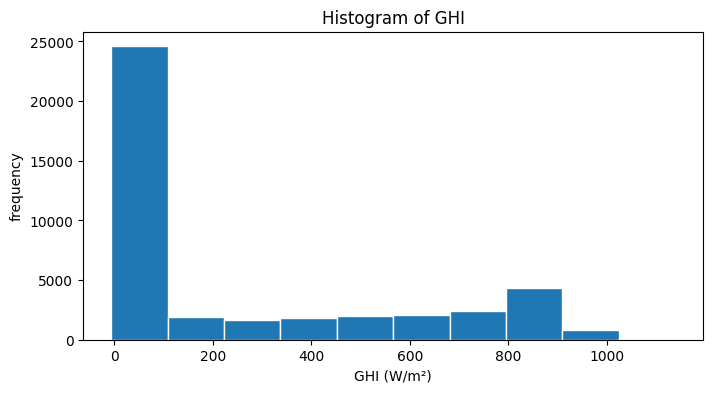

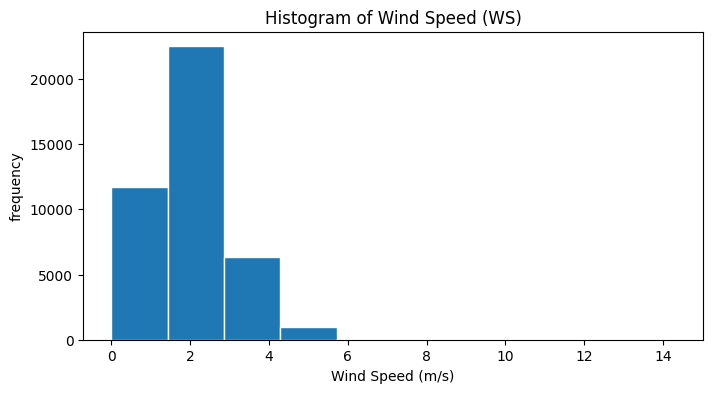

In [15]:
def plotHist(xcol, title, xlabel):
    plt.figure(figsize=(8, 4))
    plt.hist(df[xcol], bins=10, edgecolor="white")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("frequency")
    plt.show()


plotHist("GHI", "Histogram of GHI", "GHI (W/m²)")
plotHist("WS", "Histogram of Wind Speed (WS)", "Wind Speed (m/s)")


## Temperature analysis

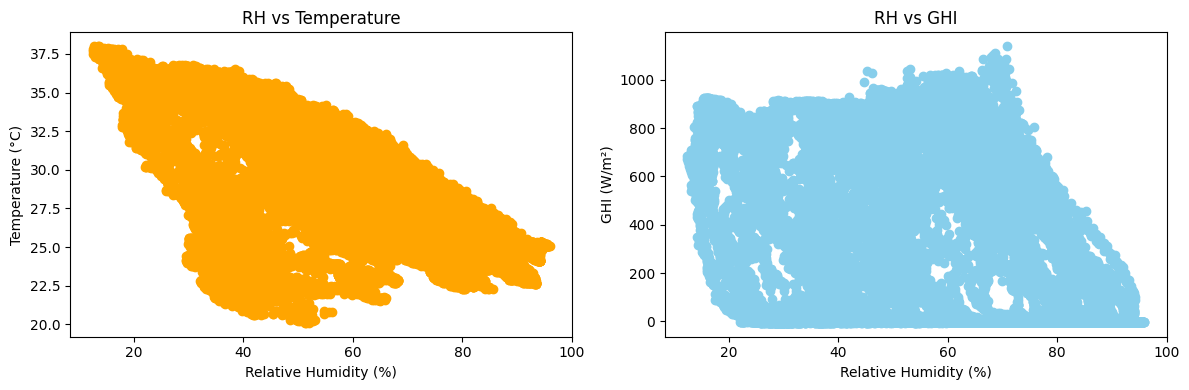

In [16]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.scatter(df['RH'], df['Tamb'], color='orange')
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Temperature (°C)")
plt.title("RH vs Temperature")

plt.subplot(1,2,2)
plt.scatter(df['RH'], df['GHI'], color='skyblue')
plt.xlabel("Relative Humidity (%)")
plt.ylabel("GHI (W/m²)")
plt.title("RH vs GHI")

plt.tight_layout()
plt.show()

## Bubble Chart

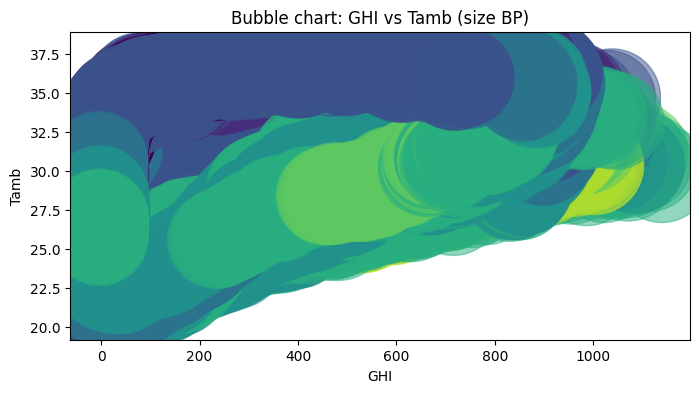

In [17]:
def bubble_chart(var_one, var_two, var_three):
    x = df[var_one]
    y = df[var_two]
    bubble = df[var_three]
    color=df[var_three]

    plt.figure(figsize=(8,4))
    plt.scatter(x, y, s=bubble*5,c=color, cmap='viridis', alpha=0.5)
    plt.title(f"Bubble chart: {var_one} vs {var_two} (size {var_three})")
    plt.xlabel(var_one)
    plt.ylabel(var_two)
    plt.show()

bubble_chart('GHI','Tamb','BP')